# Классификация SI > 8

Необходимо сравнить различные модели с настройкой гиперпараметров для бинарной классификации соединений по клинически значимому порогу индекса селективности (SI > 8) на основе их молекулярных дескрипторов.

Целевая переменная представляет собой бинарный признак, где 1 соответствует соединениям с SI > 8, что соответствует высокоселективным соединениям, обладающих хорошим терапевтическим окном и считающимся перспективными кандидатами для дальнейших исследований, а 0 — соединениям с SI ≤ 8.

Пороговое значение 8 часто используется в фармакологических исследованиях как индикатор приемлемого соотношения эффективности и безопасности.

Индекс селективности SI вычисляется как отношение CC50 к IC50, поэтому IC50 и CC50 не могут использоваться в качестве признаков при моделировании во избежание утечки данных.

Данная задача позволяет идентифицировать наиболее перспективные соединения, соответствующие клиническим критериям отбора.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import VarianceThreshold

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Загрузка данных

In [ ]:
df = pd.read_csv('/data/clean_data.csv')
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


## Подготовка данных к обучению модели

Так как в исходном датасете отсутствует целевая переменная необходимая для данной задачи создадим ее. Затем разделим данные на X, где будут все признаки и y, где будет только что созданная целевая переменная.

Для того чтобы избежать утечки информации в модель, важно исключить из рассмотрения признаки 'СC50, mM' и 'SI'.

In [ ]:
# Формирование целевой переменной
df['SI_tgt'] = (df['SI'] > 8).astype(int)

X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'SI_tgt'])
y = df['SI_tgt']
X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,SI_high
0,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,...,0,0,0,0,0,0,0,3,0,1
1,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,...,0,0,0,0,0,0,0,3,0,1
2,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,186,...,0,0,0,0,0,0,0,3,0,0
3,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,164,...,0,0,0,0,0,0,0,4,0,1
4,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,184,...,0,0,0,0,0,0,0,0,0,0


Рассмотрим распределение целевой переменной и проверим сбалансированность классов:

In [ ]:
class_counts = df['SI_tgt'].value_counts()
class_counts

,count
SI_tgt,
0,626
1,343


Для наглядности визуализируем распределение признака SI на грфике и отобразим значение медианы. Дополнительно построим график распределения целевой переменной.

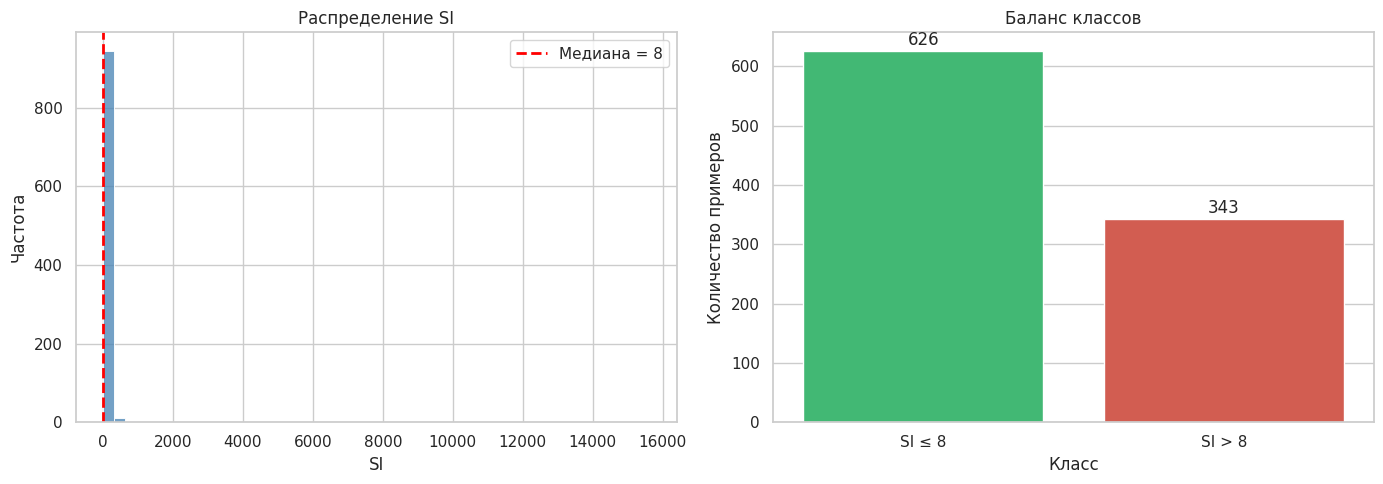

In [ ]:
sns.set(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Распределение IC50 с медианой
sns.histplot(df['SI'], bins=50, kde=False, color='steelblue', ax=ax1)
ax1.axvline(8, color='red', linestyle='--', linewidth=2, label=f'Медиана = {8}')
ax1.set_title('Распределение SI')
ax1.set_xlabel('SI')
ax1.set_ylabel('Частота')
ax1.legend()

class_data = pd.DataFrame({
    'Классы': ['SI ≤ 8', 'SI > 8'],
    'Количество': class_counts.values
})
sns.barplot(data=class_data, x='Классы', y='Количество', hue='Классы',
            palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Баланс классов')
ax2.set_ylabel('Количество примеров')
ax2.set_xlabel('Класс')

# Добавление подписей на столбцы
for i, v in enumerate(class_counts.values):
    ax2.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

На левом графику выше определили пороговое значение, равное 8. По правому графику можно сделать вывод о том, что классы распределены неравномерно и соединений, которые обладают значение SI менее или равное 8 - практически в два раза больше по сравнению с противоположным классом. Попробуем построить модели без дополнительной обработки данных.

Разделим данные на тренировочную и тестовую выборки в соотношении 80 к 20:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
X_train.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,SI_high
946,14.652714,14.652714,0.033015,-1.012348,0.260391,17.466667,610.799,564.431,610.351906,238,...,0,0,0,0,0,0,0,0,0,1
659,12.332609,12.332609,0.036502,-0.233355,0.797040,37.250000,270.332,252.188,270.136828,104,...,0,0,0,0,0,0,0,0,1,1
517,13.110844,13.110844,0.132670,-4.772189,0.735412,42.550000,292.301,273.149,292.139863,114,...,0,0,0,0,0,0,0,0,0,0
681,12.307796,12.307796,0.107617,-0.214884,0.634981,33.826087,328.437,308.277,328.124549,120,...,0,0,0,0,0,0,0,0,0,1
883,6.598611,6.598611,0.196181,0.196181,0.607378,57.000000,179.307,158.139,179.167400,74,...,0,0,0,0,0,0,0,0,0,1


Дополнительно обработаем данные с помощью VarianceThreshold, который позволит нам удалить константные признаки, так как такие признаки не несут никакой полезной информации для предсказания (их дисперсия = 0), но по сравнению с другими задачами в данной задаче негативно влияют на предсказания модели, создавая шум.

In [ ]:
# Удаляем признаки с нулевой дисперсией
selector_var = VarianceThreshold(threshold=0)
X_train = selector_var.fit_transform(X_train)
X_test = selector_var.transform(X_test)

# Получаем оставшиеся признаки
remaining_features = X.columns[selector_var.get_support()]
print(f"Осталось признаков: {len(remaining_features)}")

Осталось признаков: 191


## Обучение моделей

Для данной задачи будем рассматривать 4 различные модели классификации: логистическая регрессия, случайный лес, градиентный бустинг и XGBoost.

Для каждой модели проводится подбор гиперпараметров с помощью GridSearchCV и кросс-валидации, в качестве метрики оптимизации выбрана площадь под ROC-кривой (ROC-AUC).

Оценивать качество моделей будем по трем метрикам:

- точность (Accuracy)

- F1-мера (F1-score)

- площадь под ROC-кривой (ROC-AUC)

Логистическая регрессия предваряется стандартизацией признаков с помощью StandardScaler в составе конвейера. Все модели используют фиксированный random_state=42 для воспроизводимости результатов.



In [ ]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba)
    }

Выше представлена общая функция для предсказания и оценки модели. После подбора гиперпараметров для каждой модели извлекаются лучшие параметры, затем модели оцениваются на тестовой выборке по всем трем метрикам.

**Логистическая регрессия**

In [ ]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

params_log = {
    'model__C': [0.01, 0.1, 1, 10]
}

grid_log = GridSearchCV(logreg, params_log, cv=5, scoring='roc_auc')
grid_log.fit(X_train, y_train)

res_log = evaluate(grid_log.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_log.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_log.best_score_:.4f}")

Лучшие параметры: {'model__C': 0.01}
Наилучшая метрика ROC-AUC: 0.9070


**Случайный лес**

In [ ]:
rf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, params_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

res_rf = evaluate(grid_rf.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_rf.best_score_:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Наилучшая метрика ROC-AUC: 0.8872


**Градиентный бустинг**

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

params_gb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(gb, params_gb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)

res_gb = evaluate(grid_gb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_gb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Наилучшая метрика ROC-AUC: 0.9172


**XGBoost**

In [ ]:
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

params_xgb = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb_clf, params_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

res_xgb = evaluate(grid_xgb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_xgb.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_xgb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Наилучшая метрика ROC-AUC: 0.9201


Соберем датафрейм с результатами моделей:

In [ ]:
results = pd.DataFrame({
    'LogReg': res_log,
    'RandomForest': res_rf,
    'GradientBoosting': res_gb,
    'XGBoost': res_xgb
}).T

results.sort_values('ROC_AUC', ascending=False)

,Accuracy,F1,ROC_AUC
XGBoost,0.860825,0.818792,0.938551
GradientBoosting,0.829897,0.784314,0.926493
LogReg,0.824742,0.746269,0.919072
RandomForest,0.829897,0.722689,0.911884


По результатам классификации целевой переменной SI > 8 лучшей моделью стал XGBoost, показавший отличные результаты: ROC-AUC = 0.939, точность = 0.861 и F1 = 0.819. Градиентный бустинг и случайный лес продемонстрировали приблизительно одинаковую точность, однако градиентный бустинг существенно превзошел случайный лес по F1-мере, что указывает на лучший баланс между полнотой и точностью. Логистическая регрессия заняла предпоследнее место, и ее F1-мера оказалась выше, чем у RandomForest, несмотря на более низкую точность.

Ключевое отличие данной задачи от классификации SI > медианы - улучшение качества всех моделей. Если при бинаризации по медиане лучший ROC-AUC составлял лишь 0.721, то при пороге > 8 показатель достигает 0.939, что является отличным результатом. Это объясняется тем, что порог > 8 выделяет молекулы с действительно высокой селективностью, которые сильнее отличаются по своим свойствам от остальных, тогда как медиана размывает границы между классами. XGBoost уверенно лидирует во всех метриках, подтверждая свою эффективность на сложных нелинейных зависимостях.

**Рекомендации:**

В качестве финальной модели для предсказания SI > 8 рекомендуется XGBoost с лучшими показателями. Для дальнейшего улучшения можно провести более тонкую настройку гиперпараметров, например, оптимизировать параметры под существующий дисбаланс классов или добавить регуляризацию.
